In [1]:
import pandas as pd

In [5]:
pd.read_csv("diabetes.csv")


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [6]:
data=pd.read_csv("diabetes.csv")


In [9]:
 X=data.drop('Outcome',axis=1)
y=data['Outcome']

In [10]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [12]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [19]:
y_scores=model.predict_proba(X_test)[:,1]
y_scores

array([0.27588579, 0.18843898, 0.1144849 , 0.16354136, 0.47152271,
       0.44183494, 0.01546079, 0.6607933 , 0.54146111, 0.77733541,
       0.25592192, 0.89734083, 0.33620148, 0.30304211, 0.08198372,
       0.38093459, 0.13935707, 0.07479697, 0.86673894, 0.56142182,
       0.20841856, 0.0773983 , 0.53963168, 0.0945863 , 0.53949341,
       0.88553988, 0.12431545, 0.03016442, 0.25152592, 0.11581956,
       0.91112529, 0.87076108, 0.76535257, 0.83753052, 0.61668807,
       0.68327989, 0.96813365, 0.24364554, 0.51148617, 0.73613335,
       0.06983781, 0.59414551, 0.5836869 , 0.32717521, 0.02759113,
       0.50238953, 0.63937156, 0.22533812, 0.36057369, 0.95629652,
       0.04889692, 0.66096673, 0.8116814 , 0.24551972, 0.09325934,
       0.04152265, 0.77816989, 0.00570463, 0.40861336, 0.75695112,
       0.74134592, 0.35193939, 0.19238074, 0.20492603, 0.07688445,
       0.62715896, 0.05091845, 0.73283917, 0.03692082, 0.71593392,
       0.67524166, 0.07016722, 0.18116147, 0.1143035 , 0.09115

In [20]:
from sklearn.metrics import roc_curve

In [21]:
fpr,tpr,thresholds=roc_curve(y_test,y_scores)

In [23]:
thresholds # 0to 1

array([       inf, 0.97115296, 0.96813365, 0.95629652, 0.90261605,
       0.89734083, 0.80096783, 0.77816989, 0.77787987, 0.77733541,
       0.73283917, 0.72428628, 0.68327989, 0.67524166, 0.66096673,
       0.6607933 , 0.6555643 , 0.64966475, 0.63937156, 0.61668807,
       0.60580392, 0.5836869 , 0.55036833, 0.53949341, 0.53417474,
       0.50297018, 0.50238953, 0.42046993, 0.42016016, 0.40861336,
       0.38093459, 0.33903629, 0.32717521, 0.30304211, 0.30268413,
       0.25731783, 0.24066003, 0.22533812, 0.22515574, 0.20841856,
       0.20492603, 0.16354136, 0.14043459, 0.12822988, 0.1269864 ,
       0.1144849 , 0.1143035 , 0.04152265, 0.04048157, 0.00417353])

In [24]:
import plotly.graph_objects as go
import numpy as np

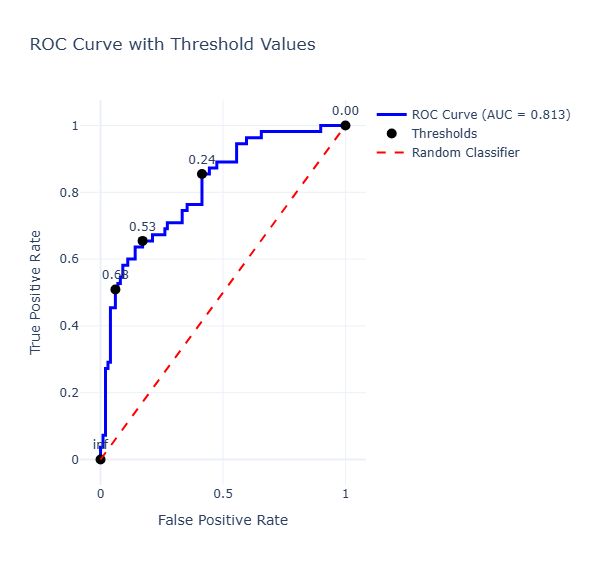

In [30]:
from sklearn.metrics import roc_curve, auc
import plotly.graph_objects as go

# Compute ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_scores)

# Compute AUC
roc_auc = auc(fpr, tpr)

# Select 5 threshold points evenly spaced
num_points = 5
indices = np.linspace(0, len(thresholds) - 1, num_points, dtype=int)

# Create figure
fig = go.Figure()

# ROC curve
fig.add_trace(go.Scatter(
    x=fpr,
    y=tpr,
    mode='lines',
    name=f'ROC Curve (AUC = {roc_auc:.3f})',
    line=dict(color='blue', width=3)
))

# Threshold marker points
fig.add_trace(go.Scatter(
    x=fpr[indices],
    y=tpr[indices],
    mode='markers+text',
    text=[f"{thresholds[i]:.2f}" for i in indices],
    textposition="top center",
    marker=dict(size=10, color='black'),
    name='Thresholds'
))

# Random classifier line
fig.add_trace(go.Scatter(
    x=[0, 1],
    y=[0, 1],
    mode='lines',
    line=dict(color='red', dash='dash'),
    name='Random Classifier'
))

# Layout
fig.update_layout(
    title='ROC Curve with Threshold Values',
    xaxis_title='False Positive Rate',
    yaxis_title='True Positive Rate',
    template='plotly_white',
    width=750,
    height=550
)

# Show figure
fig.show()

In [29]:
# assume that for fpr, tpr,theresholds have qalready been calculated
optimal_idx=np.argmax(tpr-fpr)
optimal_threshold= thresholds[optimal_idx]
print ("Optimal Threshold is : ",optimal_threshold)
# also giving the auc value for roc

Optimal Threshold is :  0.5503683269182597
